In [1]:
#installing required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn flask joblib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [4]:
#loading the dataset
df = pd.read_csv("house_prices (2).csv")
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [5]:
#understanding of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


In [6]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [7]:
df.isnull().sum()

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

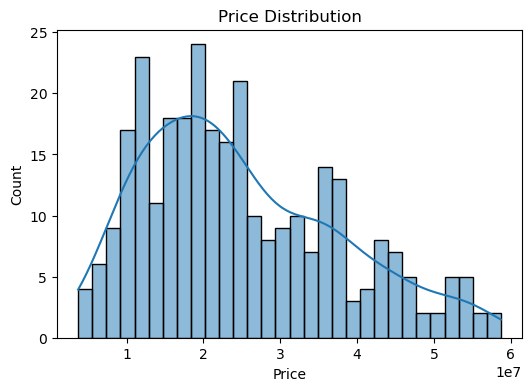

In [9]:
#performing Exploratory Data Analysis
#price distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

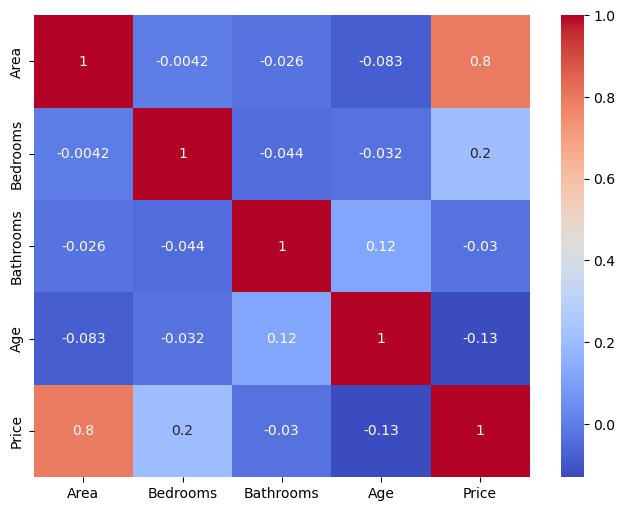

In [10]:
#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [11]:
#data pre-processing
#encode categorical variables
le_location = LabelEncoder()
le_property = LabelEncoder()

df['Location'] = le_location.fit_transform(df['Location'])
df['Property_Type'] = le_property.fit_transform(df['Property_Type'])

In [13]:
#drop un-necessary columns
df = df.drop("Property_ID", axis=1)

In [14]:
#define features and target
X = df.drop("Price", axis=1)
y = df["Price"]

In [15]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
#Train machine learning model
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
#make prediction
y_pred = model.predict(X_test)

In [19]:
#evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5411099.797604775
MSE: 42074706077812.28
RMSE: 6486501.83672311
R2 Score: 0.7045684833622563


In [20]:
#save the model
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [21]:
#save encoders
joblib.dump(le_location, "location_encoder.pkl")
joblib.dump(le_property, "property_encoder.pkl")

['property_encoder.pkl']

In [22]:
#create prediction function
def predict_price(area, bedrooms, bathrooms, age, location, property_type):

    location_enc = le_location.transform([location])[0]
    property_enc = le_property.transform([property_type])[0]

    data = np.array([[area, bedrooms, bathrooms, age, location_enc, property_enc]])

    prediction = model.predict(data)

    return prediction[0]

In [23]:
#test prediction 
predict_price(
    area=2000,
    bedrooms=3,
    bathrooms=2,
    age=5,
    location="Suburb",
    property_type="House"
)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


16904011.727832876